In [193]:
from mt5linux import MetaTrader5
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
import matplotlib.pyplot as plt

# SYMBOL = os.environ["SYMBOL"]
# LOGIN = 1000751557
# PASSWORD = "ftJUH19@"

# mt5 = MetaTrader5()
# success = mt5.initialize(
#     server="ClearInvestimentos-CLEAR",
#     login=LOGIN,
#     password=PASSWORD,
# )

In [198]:
df['buy'].astype(int) == 1

time_msc
2026-02-20 10:03:00.001    False
2026-02-20 10:03:00.001    False
2026-02-20 10:03:00.001    False
2026-02-20 10:03:00.001    False
2026-02-20 10:03:00.001    False
                           ...  
2026-02-20 11:59:31.034     True
2026-02-20 11:59:56.220     True
2026-02-20 11:59:57.898     True
2026-02-20 11:59:57.903     True
2026-02-20 11:59:58.188     True
Name: buy, Length: 2166, dtype: bool

In [146]:
df = pd.read_csv('PETR3.csv',sep='\t', index_col=0, parse_dates=True)
df['time_msc'] = df.index.astype('int64') // 10**3
print(df.shape)
df.head()

(2166, 6)


,bid,ask,last,volume,buy,time_msc
time_msc,,,,,,
2026-02-20 10:03:00.001,41.5,41.11,40.79,4100,False,1771581780001
2026-02-20 10:03:00.001,41.5,41.11,40.79,4400,False,1771581780001
2026-02-20 10:03:00.001,41.5,41.11,40.79,500,False,1771581780001
2026-02-20 10:03:00.001,41.5,41.11,40.70,400,False,1771581780001
2026-02-20 10:03:00.001,41.5,41.11,40.61,100,False,1771581780001


In [341]:
def calculate_expected_value(x):
    time = x[:, 0]
    price = x[:, 1]
    volume = x[:, 2]
    buy = x[:, 3]
    last_price = price[-1]
    last_time = time[-1]
    is_buy = buy == 1
    is_sell = buy == 0
    time_interval = (last_time - time)
    max_time_interval = time_interval.max()
    normalized_time = (time_interval / max_time_interval) if max_time_interval > 0 else np.zeros_like(time_interval)
    # print(normalized_time)
    volume_total = volume.sum()
    volume_buy_total = volume[is_buy].sum()
    volume_sell_total = volume[is_sell].sum()
    volume_ratio = ((volume_buy_total - volume_sell_total) / volume_total if volume_total > 0 else 0)
    # volume[is_sell] = -volume[is_sell]
    expectancy = (last_price - price) * volume / normalized_time
    expectancy_buy = expectancy[is_buy].sum()
    expectancy_sell = -expectancy[is_sell].sum()
    expectancy_total = expectancy.sum()
    # print(expectancy_buy, expectancy_sell, expectancy_total, volume_ratio)
    return np.array([expectancy_buy, expectancy_sell, expectancy_total, volume_ratio])
    # return last_price[-1] * volume[-1] * buy[-1]
expectancy = df[['time_msc', 'last', 'volume', 'buy']].rolling(window='2min', method='table').apply(calculate_expected_value, engine='numba', raw=True).rename(columns={'time_msc': 'buy', 'last': 'sell', 'volume': 'total', 'buy': 'volume_ratio'})

In [353]:
expectancy.fillna(0, inplace=True)

,buy,sell,total,volume_ratio
time_msc,,,,
2026-02-20 10:03:00.001,0.0,0.000000,0.0,-1.000000
2026-02-20 10:03:00.001,0.0,0.000000,0.0,-1.000000
2026-02-20 10:03:00.001,0.0,0.000000,0.0,-1.000000
2026-02-20 10:03:00.001,0.0,0.000000,0.0,-1.000000
2026-02-20 10:03:00.001,0.0,0.000000,0.0,-1.000000
...,...,...,...,...
2026-02-20 11:59:31.034,0.0,-796.828845,0.0,0.056277
2026-02-20 11:59:56.220,0.0,-420.218412,0.0,0.155556
2026-02-20 11:59:57.898,0.0,-408.140237,0.0,0.191489


In [354]:
expectancy_ratio = (expectancy['buy'] - expectancy['sell']) / (expectancy['buy'] + expectancy['sell'])
expectancy_ratio.fillna(0, inplace=True)
volume_ratio = expectancy['volume_ratio']

Text(0.5, 1.0, 'Expectancy and Price')

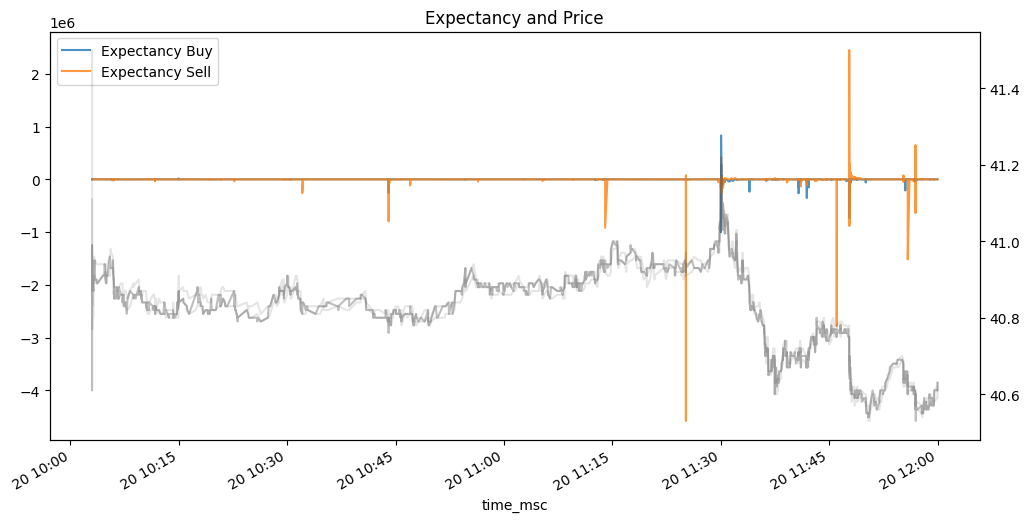

In [356]:
plt.figure(figsize=(12, 6))
expectancy['buy'].plot(alpha=0.8, label='Expectancy Buy')
expectancy['sell'].plot(alpha=0.8, label='Expectancy Sell')
# expectancy_ratio.plot(c='black', alpha=0.5, label='Expectancy Ratio')
plt.legend()
plt.twinx()
# idx = df.index[0:-1]
df['last'].plot(c='gray', alpha=0.5, label='Last Price')
# df['last'][expectancy_ratio > 0].plot(style='.',c='green', alpha=0.2, label='Expectancy Ratio Buy')
# df['last'][expectancy_ratio < 0].plot(style='.',c='red', alpha=0.2, label='Expectancy Ratio Sell')
df['ask'].plot(c="k", alpha=0.1, label='Ask')
df['bid'].plot(c="k", alpha=0.1, label='Bid')
# expectancy_ratio.plot(c='blue', alpha=0.5, label='Expectancy Ratio')

# expectancy['expectancy_total'].plot()
# plt.ylim(-500, 500)
# plt.legend()
# plt.twinx()
# df['last'].plot(color='gray', alpha=0.5)
plt.title('Expectancy and Price')
# plt.show(figsize=(12, 6))
